<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_043_decision_tree_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 43/365 — Pruning Decision Trees
## How do we stop a Decision Tree from memorizing the training data?

Over the last few days, we learned how Decision Trees choose splits using impurity and Information Gain.

But if we keep splitting, the tree can become very deep and start fitting noise.

That is where **pruning** comes in.

Pruning simplifies a tree by removing branches that do not improve generalization enough.

Today we use the real scikit-learn **Breast Cancer Wisconsin dataset** and explore **Cost-Complexity Pruning** using `ccp_alpha`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


## 1. Load the real dataset


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Train an unpruned tree

We first allow the tree to grow freely.


In [3]:
full_tree = DecisionTreeClassifier(random_state=42)

full_tree.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, full_tree.predict(X_train))
test_acc_full = accuracy_score(y_test, full_tree.predict(X_test))

print("Unpruned tree depth:", full_tree.get_depth())
print("Unpruned tree leaves:", full_tree.get_n_leaves())
print("Training accuracy:", round(train_acc_full, 3))
print("Test accuracy:", round(test_acc_full, 3))


Unpruned tree depth: 7
Unpruned tree leaves: 18
Training accuracy: 1.0
Test accuracy: 0.923


## 3. Candidate pruning strengths

`ccp_alpha` controls how strongly we penalize tree complexity.

- `ccp_alpha = 0` → no pruning
- larger `ccp_alpha` → more pruning


In [4]:
path_info = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path_info.ccp_alphas

print("Number of candidate alpha values:", len(ccp_alphas))
print("First few:", np.round(ccp_alphas[:10], 6))


Number of candidate alpha values: 13
First few: [0.       0.002319 0.00313  0.004225 0.004565 0.005321 0.005634 0.006338
 0.008142 0.014877]


## 4. Train trees across pruning strengths


In [5]:
rows = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    model.fit(X_train, y_train)

    rows.append({
        "ccp_alpha": alpha,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

results = pd.DataFrame(rows)
display(results.head(10).round(4))


,ccp_alpha,Train Accuracy,Test Accuracy,Depth,Leaves
0,0.0000,1.0000,0.9231,7,18
1,0.0023,0.9930,0.9371,5,12
2,0.0031,0.9906,0.9371,5,11
3,0.0042,0.9883,0.9441,4,10
4,0.0046,0.9859,0.9441,4,9
5,0.0053,0.9836,0.9441,4,8
6,0.0056,0.9789,0.9371,4,7
7,0.0063,0.9742,0.9441,3,6
8,0.0081,0.9718,0.9441,3,5
9,0.0149,0.9577,0.9091,2,4


## 5. Visual — pruning strength vs accuracy

As pruning gets stronger, the tree becomes simpler.

The important question is whether test performance stays stable or improves.


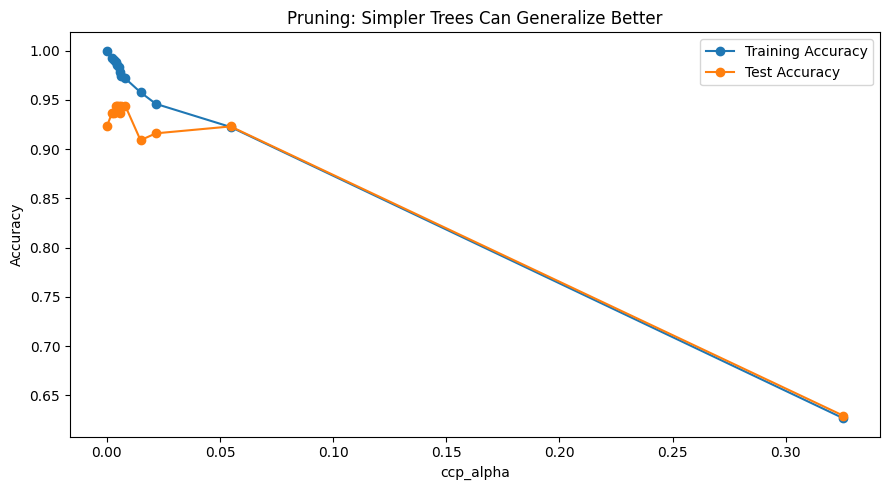

In [6]:
plt.figure(figsize=(9,5))

plt.plot(
    results["ccp_alpha"],
    results["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results["ccp_alpha"],
    results["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Pruning: Simpler Trees Can Generalize Better")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Pick a useful alpha for visualization

For real model selection, choose `ccp_alpha` using validation or cross-validation.

Here, we identify the best test-performing value only to make the pruning effect easy to visualize in this educational notebook.


In [7]:
best_index = results["Test Accuracy"].idxmax()
best_alpha = results.loc[best_index, "ccp_alpha"]

print("Best demonstration alpha:", round(best_alpha, 6))
print(results.loc[best_index].round(4))


Best demonstration alpha: 0.004225
ccp_alpha          0.0042
Train Accuracy     0.9883
Test Accuracy      0.9441
Depth              4.0000
Leaves            10.0000
Name: 3, dtype: float64


## 7. Visualize the pruned tree


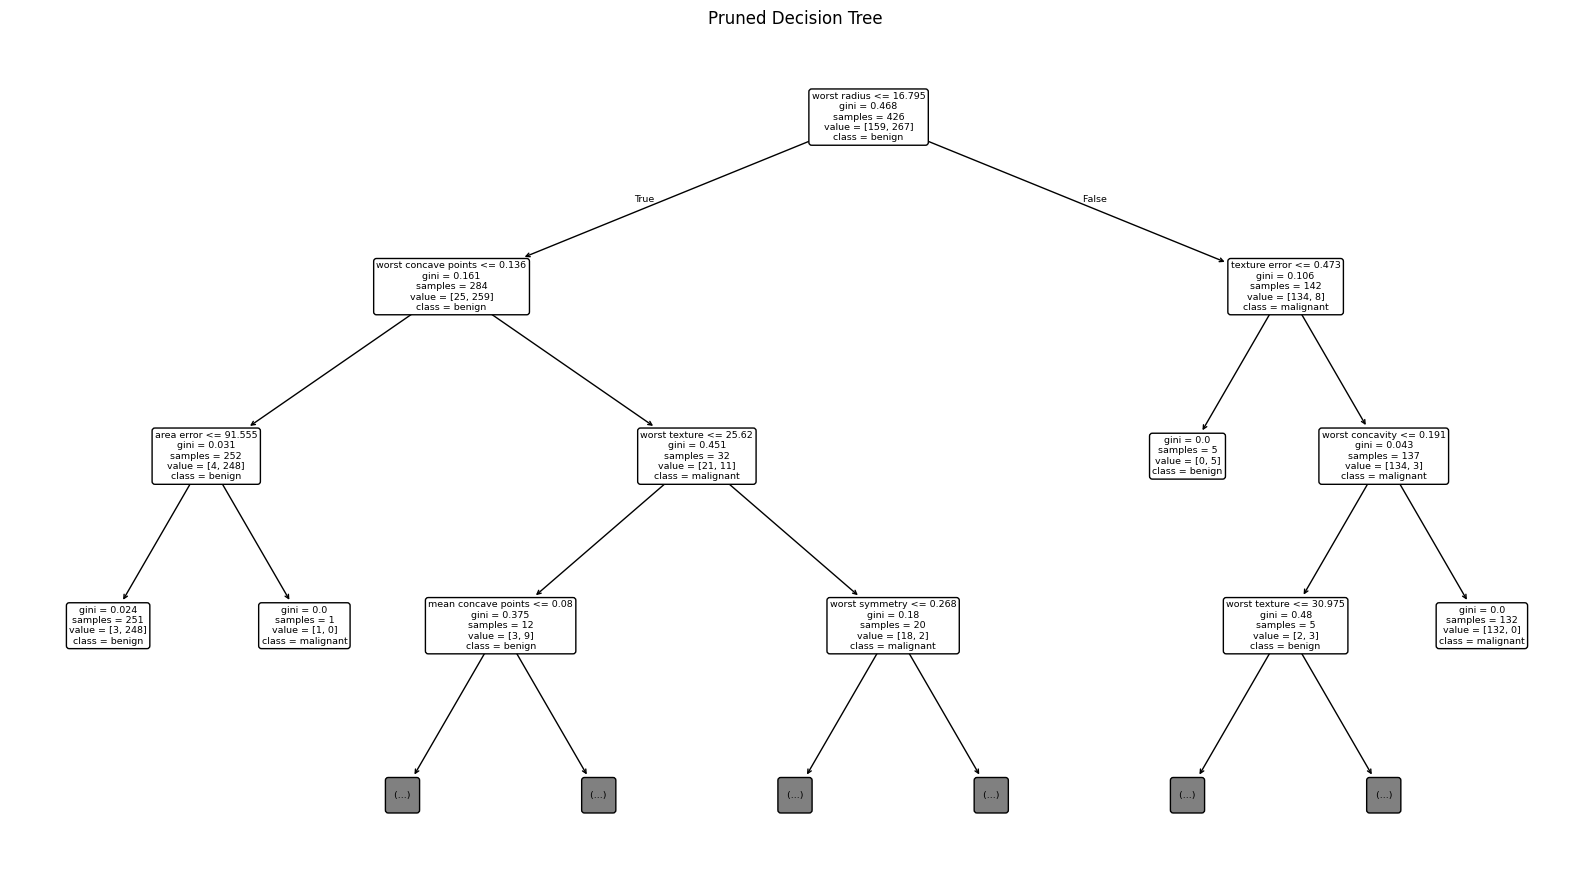

In [8]:
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

pruned_tree.fit(X_train, y_train)

plt.figure(figsize=(16,9))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=False,
    rounded=True,
    max_depth=3
)

plt.title("Pruned Decision Tree")
plt.tight_layout()
plt.show()


## Enterprise intuition

Imagine a fraud or claims model.

An unpruned tree may learn extremely specific historical rules that fit the training data perfectly but fail on future cases.

Pruning removes branches whose extra complexity is not valuable enough.

That can produce a model that is:

- simpler
- more stable
- easier to explain
- less likely to overfit


## What does this experiment teach?

- Decision Trees can overfit by growing too deep.
- Pruning reduces unnecessary complexity.
- `ccp_alpha` controls cost-complexity pruning in scikit-learn.
- Stronger pruning generally creates shallower trees with fewer leaves.
- Training accuracy may decrease while generalization stays the same or improves.
- In real projects, pruning strength should be chosen using validation or cross-validation.

> **The goal is not to build the biggest tree. It is to build the simplest tree that still generalizes well.**


## References

- https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
- https://scikit-learn.org/stable/modules/tree.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
